# Assemble green function with AE event:  remove response
2022.02.15 Kurama Okubo

2022.05.08 update for fb03-045

2022.07.29 update for removal response using PAZ

2022.12.05 update for removal response with preamp, AE sensor and the source factor obtained from the ball drop.

2023.07.24 update for fb03-087

2023.10.22 update for fb03-087 multiple events

2024.2.6 update for master plot: replaced the ball drop gain model to model 4 including the aperture effect

2024.6.9 update for the Küpper wavelet as the source time function

2024.6.27 modified to process the different gouge event: G5. Only save the observation data.

2025.12.3 update to process the GP events generated from P5 for revision.

## Work flow

1. Read isocoord pickle associated with stations
2. Read meta data
3. Read synthetic waveform
4. Preprocess (unscale using gain to the observation **& remove response**)
4. Save pickle

In [1]:
import os
import obspy
from obspy import read, Stream, Trace
from obspy.signal.invsim import paz_to_freq_resp

from scipy import signal
import scipy.io as sio
import matplotlib.pyplot as plt
%matplotlib inline
import glob
from glob import glob
import numpy as np
import pandas as pd
import datetime
from datetime import timedelta
from tqdm import tqdm
import warnings

%load_ext autoreload
%autoreload 2

from remove_resp_digitalfilt import *

os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion

plt.rcParams["font.family"] = 'Arial'
# plt.rcParams["font.sans-serif"] = "DejaVu Sans, Arial, Helvetica, Lucida Grande, Verdana, Geneva, Lucid, Avant Garde, sans-serif"
plt.rcParams["font.size"] = 12
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["xtick.major.width"] = 0.5
plt.rcParams["xtick.minor.size"] = 2
plt.rcParams["xtick.minor.width"] = 1
plt.rcParams["xtick.minor.visible"] = True


plt.rcParams["ytick.direction"] = "in"
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.major.width"] = 0.5
plt.rcParams["ytick.minor.size"] = 2
plt.rcParams["ytick.minor.width"] = 1
plt.rcParams["ytick.minor.visible"] = True

    
os.environ['TZ'] = 'GMT' # change time zone to avoid confusion in unix_tvec conversion

from obspy.core.utcdatetime import UTCDateTime  
UTCDateTime.DEFAULT_PRECISION = 8 # increase the time precision


In [2]:
#Parameters
simulationtitle = 'MTinv_fb03-087' # to read sac, set simulation title used in Input.inf of OpenSWPC

balldrop_model=4 # 2 for the model only with SiTj, 4 for the SiTjbeta

# rootdir for removal resp analysis
rootdir = "./"
# Sensor gain
fi_balldropgain = rootdir+f'../../../../../Calibration/SensorCoupling_BallDrop/data/DATA_surfaceeffect_Aij_Case2/master_gain_model{balldrop_model}.csv'
# fi_balldropgain = rootdir+f'../data/resp/master_gain_model3.csv' # debug
fi_AEresp = rootdir+'../../../../../Calibration/AEsensor_Calibration/AEsensor_Calibration_ARX/data/AE_resp_dataandcoef_fronttop.mat'
# fi_AEresp = rootdir+'../data/resp/debug_AE_resp_dataandcoef_fronttop.mat' # debug
fi_preamp = rootdir+'../data/resp/preamp_mistras_resp.mat'
figdir = "../figure"

fontsize = 12
vmean = 6200
fs = 1e7; # sampling frequency

# Pre-amplification
preamp_dB = 40 # [dB]
preamp_V = 10 ** (preamp_dB/20)
preamp_V

100.0

# Test of removal response using metal block test
We first test to remove the response using metal block data.
The coefficients of PAZ are estimated using matlab code.

In [3]:
D = sio.loadmat(fi_AEresp);
D.keys()

dict_keys(['__header__', '__version__', '__globals__', 'AIC', 'Na', 'Nb', 'k', 'p', 'tf_a', 'tf_b', 'u_input_raw', 'u_normfact', 'y_output_raw', 'z'])

In [4]:
np.squeeze(D["u_input_raw"])

array([1.98263840e-05, 2.47079860e-05, 2.48935806e-05, ...,
       2.91986732e-06, 1.87184595e-05, 1.40819017e-05])

In [5]:
# compile trace
st_mb = Stream()
tr_u = Trace()
tr_u.stats.starttime = datetime.datetime(2022,7,29)
tr_u.stats.sampling_rate = fs
tr_u.stats.network = "N"
tr_u.stats.station = "IN"
tr_u.stats.channel = "Z"
tr_u.data = np.squeeze(D["u_input_raw"])

tr_y = tr_u.copy()
tr_y.stats.station = "OUT"
tr_y.stats.channel = "Z"
tr_y.data = np.squeeze(D["y_output_raw"])


In [6]:
tr_y.stats

         network: N
         station: OUT
        location: 
         channel: Z
       starttime: 2022-07-29T00:00:00.00000000Z
         endtime: 2022-07-29T00:00:00.00010000Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 1001
           calib: 1.0

In [7]:
# remove response using the function
poles_AE = np.squeeze(D["p"])
zeros_AE = np.squeeze(D["z"])
scale_fac_AE = np.squeeze(D["k"])
u_normfact_AE = np.squeeze(D["u_normfact"])
pre_filt = (1e4, 2e4, 1e6, 2e6)
water_level = 60

# debug
# scale_fac_AE /= u_normfact_AE

tr_removed = remove_resp_digitalfilt(tr_y, poles_AE, zeros_AE, scale_fac_AE, pre_filt=pre_filt, water_level=60, zero_mean=True,
    taper=True, taper_fraction=0.05, detrend=True, debug=False)

In [8]:
freqmin = 6e4
freqmax = 3e5

tr_u_filtered = tr_u.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True)
tr_inv_filtered = tr_removed.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True)
tr_y_filtered =  tr_y.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True)

(0.0, 100.0)

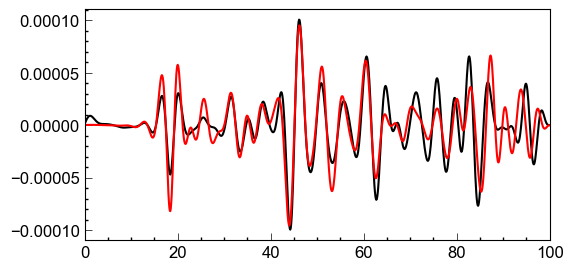

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
tvec = tr_u_filtered.times()*1e6
ax.plot(tvec, tr_u_filtered.data, "k-", label="LDV")
ax.plot(tvec, tr_inv_filtered.data, "r-", label="inverted")
# ax.plot(tvec, tr_y_filtered.data/5e4, "b--", label="inverted")
ax.set_xlim([0, 100])



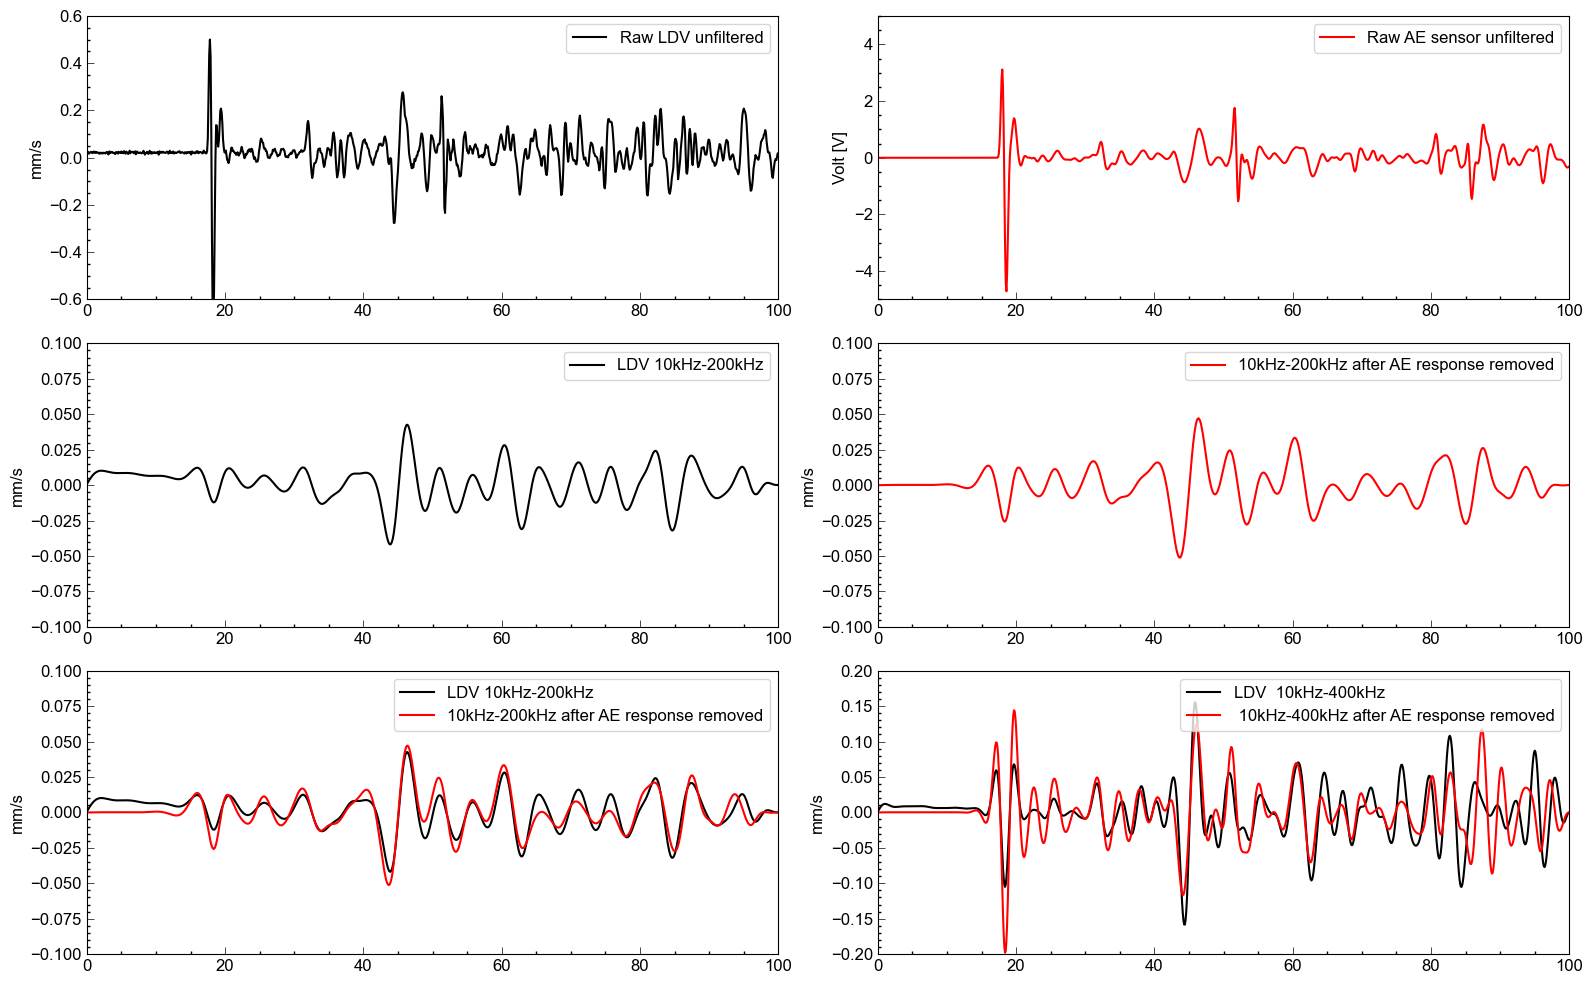

In [10]:
freqmin = 1e4
freqmax = 2e5
freqmax_high = 4e5

fig, axs = plt.subplots(3, 2, figsize=(16, 10))
tvec = tr_u_filtered.times()*1e6

axs[0,0].plot(tvec, tr_u.data*1e3, "k-", label="Raw LDV unfiltered")
axs[0,0].set_ylim([-0.6, 0.6])
axs[0,0].set_ylabel("mm/s")

axs[0,1].plot(tvec, tr_y.data, "r-", label="Raw AE sensor unfiltered")
axs[0,1].set_ylim([-5.0, 5.0])
axs[0,1].set_ylabel("Volt [V]")

axs[1,0].plot(tvec, tr_u.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True).data*1e3, "k-", label=f"LDV {int(freqmin/1e3)}kHz-{int(freqmax/1e3)}kHz")
axs[1,0].set_ylim([-0.1, 0.1])
axs[1,0].set_ylabel("mm/s")

axs[1,1].plot(tvec, tr_removed.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True).data*1e3, "r-",
                                          label=f"{int(freqmin/1e3)}kHz-{int(freqmax/1e3)}kHz after AE response removed")
axs[1,1].set_ylim([-0.1, 0.1])
axs[1,1].set_ylabel("mm/s")

axs[2,0].plot(tvec, tr_u.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True).data*1e3, "k-", label=f"LDV {int(freqmin/1e3)}kHz-{int(freqmax/1e3)}kHz")
axs[2,0].plot(tvec, tr_removed.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=3, zerophase=True).data*1e3, "r-",label=f"{int(freqmin/1e3)}kHz-{int(freqmax/1e3)}kHz after AE response removed")
axs[2,0].set_ylim([-0.1, 0.1])
axs[2,0].set_ylabel("mm/s")

axs[2,1].plot(tvec, tr_u.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax_high, corners=3, zerophase=True).data*1e3, "k-", label=f"LDV  {int(freqmin/1e3)}kHz-{int(freqmax_high/1e3)}kHz")
axs[2,1].plot(tvec, tr_removed.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax_high, corners=3, zerophase=True).data*1e3, "r-",label=f" {int(freqmin/1e3)}kHz-{int(freqmax_high/1e3)}kHz after AE response removed")
axs[2,1].set_ylim([-0.2, 0.2])
axs[2,1].set_ylabel("mm/s")


for ax_h in axs:
    for ax in ax_h:
        ax.legend(loc=1)
        ax.set_xlim([0, 100])
        
plt.tight_layout()
# plt.savefig(figdir+"/LDVandAE_comparison.png", dpi=300)


## Plot poles and zeros

Text(0.5, 1.0, 'Npoles:24 Nzeros:11')

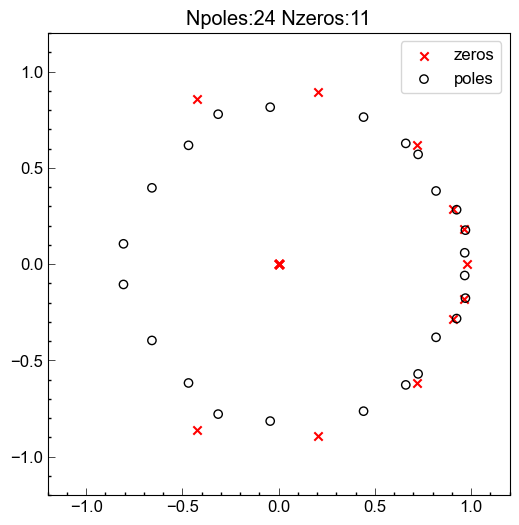

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

poles_AE.size, np.count_nonzero(zeros_AE)

ax.scatter([np.real(x) for x in zeros_AE], [np.imag(x) for x in zeros_AE], label="zeros",
           marker="x", c="r")
ax.scatter([np.real(x) for x in poles_AE], [np.imag(x) for x in poles_AE], label="poles",
           marker="o", fc="None", ec="k")
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])
ax.set_aspect('equal')
ax.legend(loc=1)
ax.set_title(f"Npoles:{poles_AE.size} Nzeros:{np.count_nonzero(zeros_AE)}")

# Bode plot

In [12]:
_, freqs, freq_domain_taper, data_after_freqtapered, freq_response_forward, freq_response = remove_resp_digitalfilt(tr_y, poles_AE, zeros_AE, scale_fac_AE, pre_filt=pre_filt, water_level=60, zero_mean=True,
    taper=True, taper_fraction=0.05, detrend=True, debug=True)

In [13]:
len(freqs)

1003

In [14]:
# compute G from just dividing y from u
from obspy.signal.util import _npts2nfft
nfft = _npts2nfft(tr_y.stats.npts)
U = np.fft.rfft(tr_u.data, n=nfft)
Y = np.fft.rfft(tr_y.data, n=nfft)
g_freqs = np.fft.rfftfreq(nfft, d=1/fs)
g_est = Y/U

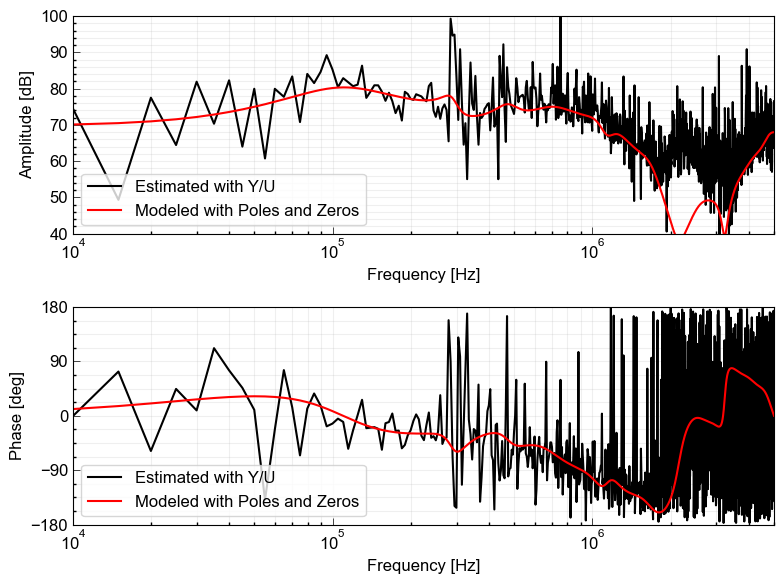

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
xlimit = [10e3, 5e6]

axs[0].grid(True, which="both", ls="-", alpha=0.2)

axs[0].semilogx(g_freqs, 20 * np.log10(abs(g_est)), "k-", label="Estimated with Y/U")
axs[0].semilogx(freqs, 20 * np.log10(abs(freq_response_forward)), "r-", label="Modeled with Poles and Zeros")

axs[0].set_xlabel("Frequency [Hz]")
axs[0].set_ylabel("Amplitude [dB]")
axs[0].set_xlim(xlimit)
axs[0].set_ylim([40, 100])
axs[0].legend(loc=3)


# angles_gest = np.unwrap(np.angle(g_est)) # unwrap the angle to make it continuous; not applied for this figure
# angles_paz = np.unwrap(np.angle(freq_response_forward))
angles_gest = np.angle(g_est)
angles_paz = np.angle(freq_response_forward)

axs[1].grid(True, which="both", ls="-", alpha=0.2)

axs[1].semilogx(g_freqs, np.rad2deg(angles_gest), 'k', label="Estimated with Y/U")
axs[1].semilogx(freqs, np.rad2deg(angles_paz), 'r', label="Modeled with Poles and Zeros")

axs[1].set_xlabel("Frequency [Hz]")
axs[1].set_ylabel('Phase [deg]')
axs[1].set_ylim([-180, 180])
axs[1].set_yticks([-180, -90, 0, 90, 180])
axs[1].set_xlim(xlimit)
axs[1].legend(loc=3)

plt.tight_layout()
# plt.savefig(figdir+"/AEsensor_bode.png", dpi=300)


In [16]:
ax

<Axes: title={'center': 'Npoles:24 Nzeros:11'}>

# Read gain factor obtained from ball drop test

In [17]:
df_gain = pd.read_csv(fi_balldropgain, index_col=0)
df_gain.loc[df_gain['AEsensor'] == "OL01"]["gainfactor"].values # this includes 40dB of pre-amplification
df_gain

,AEsensor,gainfactor
0,OL01,0.463046
1,OL02,0.393173
2,OL03,0.706840
3,OL04,0.570035
4,OL05,0.632668
5,OL06,0.420014
6,OL07,0.910917
7,OL08,0.970118
8,OL09,0.910095
9,OL10,0.836053


In [18]:
df_gain[df_gain["AEsensor"] == "OL03"]["gainfactor"].values[0]

0.706840106216344

# Read response of preamp filter

In [19]:
A = sio.loadmat(fi_preamp);
print(A.keys())

tvec = np.squeeze(A["tvec"]) # PAZ of the model for G20/G40
u_input_40 = np.squeeze(A["u_input_40"]) # PAZ of the model for G20/G40
y_output_20 = np.squeeze(A["y_output_20"]) # PAZ of the model for G20/G40
y_output_60 = np.squeeze(A["y_output_60"]) # PAZ of the model for G20/G40

PAZ_param = dict()

M20 = A["PAZ20"] # PAZ of the model for G20/G40
PAZ_param["p_20"] = np.squeeze(M20['p'][0][0])
PAZ_param["z_20"] = np.squeeze(M20['z'][0][0])
PAZ_param["k_20"] = np.squeeze(M20['k'][0][0])

M60 = A["PAZ60"] # PAZ of the model for G60/G40
PAZ_param["p_60"] = np.squeeze(M60['p'][0][0])
PAZ_param["z_60"] = np.squeeze(M60['z'][0][0])
PAZ_param["k_60"] = np.squeeze(M60['k'][0][0])


dict_keys(['__header__', '__version__', '__globals__', 'PAZ20', 'PAZ60', 'tvec', 'u_input_40', 'y_output_20', 'y_output_60'])


In [20]:
# pickle event waveform directory
eventdatadir ='../data/04_AE_obs_isocoord'

# greens function data directory 

# greendatadir =  rootdir+'./05_numericalsimulation/case_gougepatch_fb03-087_cluster_cp6200_cs3600_v4/out/green/S00'
# greendatadir =  rootdir+'./05_numericalsimulation/case_gougepatch_fb03-087_cluster_cp6200_cs3600_v5_kupper/out/green/S00'
# greendatadir =  rootdir+'./05_numericalsimulation/case_gougepatch_fb03-087_cluster_cp6200_cs3600_v6_patchG5/out/green/S00'
greendatadir =  rootdir+'./05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00'

# output datadir
outputdir = f"../data/06_assemble_gf_model{balldrop_model}"

# channel table
channel_finame = '../../../../../Others/AEchanneltable/AEsensorlocation_onFB03_table.csv'


In [21]:
if not os.path.exists(outputdir):
    os.makedirs(outputdir)

In [22]:
# read gindex table
df_gindextable = pd.read_csv("../data/datacsv/gindex_table.csv", index_col=0)
df_gindextable

,index,gid
0,OL10__fb03-087__0017,0
1,OL10__fb03-087__0023,1
2,OL10__fb03-087__0029,2
3,OL10__fb03-087__0033,3
4,OL10__fb03-087__0036,4
...,...,...
91,OL28__fb03-087__0106,91
92,OL28__fb03-087__0107,92
93,OL28__fb03-087__0108,93
94,OL28__fb03-087__0114,94


In [23]:
# read observation casename  table
df_iso_all = pd.read_csv("../data/datacsv/AEevents_isocoord.csv", index_col=0)
# reassemble event id 
event_cases = np.unique(df_iso_all["datacase"])
df_iso_all.head()

,OL,datacase,xs,ys,zs,xi,eta,zeta,xi1,eta1,zeta1,incidentangle,azimuth,rlen_sourcedist,llen
OL10__fb03-087__0017,OL10,fb03-087__0017,2.41,0.05,0.07,2.7460,-0.00325,0,0.3360,-0.05325,0,81.180823,80.994539,0.347321,0.340193
OL10__fb03-087__0023,OL10,fb03-087__0023,2.41,0.05,0.07,2.7470,-0.00325,0,0.3370,-0.05325,0,81.205516,81.020826,0.348288,0.341181
OL10__fb03-087__0029,OL10,fb03-087__0029,2.41,0.05,0.07,2.7420,-0.00575,0,0.3320,-0.05575,0,80.669149,80.467728,0.343849,0.336648
OL10__fb03-087__0033,OL10,fb03-087__0033,2.41,0.05,0.07,2.7470,-0.01100,0,0.3370,-0.06100,0,79.950050,79.740044,0.349557,0.342476
OL10__fb03-087__0036,OL10,fb03-087__0036,2.41,0.05,0.07,2.7445,-0.00400,0,0.3345,-0.05400,0,81.020810,80.829575,0.345986,0.338831


In [24]:
event_cases

array(['fb03-087__0017', 'fb03-087__0023', 'fb03-087__0029',
       'fb03-087__0033', 'fb03-087__0036', 'fb03-087__0042',
       'fb03-087__0065', 'fb03-087__0080', 'fb03-087__0090',
       'fb03-087__0093', 'fb03-087__0103', 'fb03-087__0106',
       'fb03-087__0107', 'fb03-087__0108', 'fb03-087__0114',
       'fb03-087__0115'], dtype=object)

In [25]:
# Read Channel Index
df_array = pd.read_csv(channel_finame)

channel_loc={}

for i in range(len(df_array)):
    stnm = df_array.iloc[i].Instrument_Label
    xtemp = df_array.iloc[i].North.astype('float')
    ytemp = df_array.iloc[i].East.astype('float')
    ztemp = df_array.iloc[i].Down.astype('float')
    channel_loc[stnm] = [xtemp, ytemp, ztemp]
    
AEsensors = list(channel_loc.keys())

## Assemble observation and synthetic waveform

In [26]:
# Read observation
pre_filt = (1e4, 2e4, 1e6, 2e6) # prefilter for the remove_resp
water_level = 60 # waterlevel [dB] for the remove_resp

for event_case in tqdm(event_cases):
# event_case = event_cases[1]

    foname = os.path.join(outputdir, "{}_AEwaveform.pickle".format(event_case)) 

    # if os.path.exists(foname):
    #     print("{}_bdwaveform.pickle already exists. skip this case.".format(event_case))
    #     continue

    df_iso_st = df_iso_all[df_iso_all.datacase==event_case]
    xlimit = [-0.5, 3]
    ylimit = [-1.0, 1.0]

    # if not df_iso_st:
    #     print("{}_bdwaveform.pickle already exists. skip this case.".format(stnm))
    #     continue

    df_iso_st

    st_eventsta = Stream()

    #---Start assembling each AE event---#
    for dataind in df_iso_st.index:
        #---Read observation data---#
        stnm, runID, event_id = dataind.split('__')

        tr_obs_trim = read(eventdatadir+"/obs_isocoord_{}.pickle".format(dataind))[0]
        tr_obs_trim.stats.dataindex = dataind
        # rename channel
        tr_obs_trim.stats.channel = 'OZ' # 'OZ: Observatoin in Z direction with sidecoord_seg

        #--------------------------------------------------#
        #---Remove the instrumental response---#
        #--------------------------------------------------#
        # Stage 3: deconvolve preamp filter (G60/G40)
        # Stage 2: deconvolve AE sensor + preamp +40dB
        # Stage 1: rescale with the ball-drop calibration: NOTE: the aperture effect should be removed during the waveform fitting
        
        # Stage 3:
        if preamp_dB == 60:
            tr_stage3 = remove_resp_digitalfilt(tr_obs_trim, PAZ_param["p_60"], PAZ_param["z_60"], PAZ_param["k_60"],
                                            pre_filt=pre_filt, water_level=water_level, zero_mean=True, taper=True, taper_fraction=0.05, detrend=True, debug=False)
        elif preamp_dB == 20:
            tr_stage3 = remove_resp_digitalfilt(tr_obs_trim, PAZ_param["p_20"], PAZ_param["z_20"], PAZ_param["k_20"],
                                            pre_filt=pre_filt, water_level=water_level, zero_mean=True, taper=True, taper_fraction=0.05, detrend=True, debug=False)
            
        else:
            # no application for stage 3
            tr_stage3 = tr_obs_trim
            
        # Stage 2:
        tr_stage2 = remove_resp_digitalfilt(tr_stage3, poles_AE, zeros_AE, scale_fac_AE, # update: u_normfact is already included in scale_fac_AE
                                            pre_filt=pre_filt, water_level=water_level, zero_mean=True, taper=True, taper_fraction=0.05, detrend=True, debug=False)
        
        # Stage 1: 
        tr_stage1 = tr_stage2.copy()
        sensorgain = df_gain[df_gain["AEsensor"] == stnm]["gainfactor"].values[0]
        print(sensorgain)
        tr_stage1.data = tr_stage2.data/sensorgain
        tr_stage1.stats.location="stage1"
        st_eventsta.append(tr_stage1)

        
        # append to event stream both with and without instrumental response removal
        tr_obs_trim_raw = tr_obs_trim.copy()
        tr_obs_trim_raw.stats.location="raw"
        st_eventsta.append(tr_obs_trim_raw)

        tr_obs_trim_stage3 = tr_stage3.copy()
        tr_obs_trim_stage3.stats.location="stage3"
        st_eventsta.append(tr_obs_trim_stage3)

        tr_obs_trim_stage2 = tr_stage2.copy()
        tr_obs_trim_stage2.stats.location="stage2"
        st_eventsta.append(tr_obs_trim_stage2)
        #--------------------------------------------------#
        
        #---read green's tensor---#
        # read synthetic green's function
        gid = df_gindextable[df_gindextable['index'] == dataind]['gid'].values[0]
        finame_syn = '{}/{}__{:08d}__S00__z__m*__.sac'.format(greendatadir, simulationtitle, gid) # Green's tensor in [nm/s]
        print(finame_syn, gid)
        trs_syn = read(finame_syn, format="SAC")

        # restore stats
        for tr_syn in trs_syn:
            tr_syn.stats.network = 'OL'
            tr_syn.stats.station = stnm
            tr_syn.stats.location = 'GF'
        #     tr_syn.stats.channel = '' 
            tr_syn.stats.dataindex = dataind

            # rescale source scaling and convert from nm to m
            tr_syn.data = tr_syn.data/1e9
            # manipulate start and endtime
            # 1. zero pad pretriger and windowlen
            # 2. change starttime

            T0 = 0.0 # Origin time used in OpenSWPC

            st_tmp = tr_syn.stats.starttime
            pt = timedelta(milliseconds = tr_obs_trim.stats.pretrigger)
            wt = timedelta(milliseconds = tr_obs_trim.stats.windowlen)
            ot = timedelta(milliseconds = T0)

            starttime_tmp = st_tmp+ot-pt
            endtime_tmp = st_tmp+ot+wt

            tr_syn_trim = tr_syn.copy() # avoid error in multiple trim
            tr_syn_trim.trim(starttime_tmp, endtime_tmp, pad=True, fill_value=0.0)
            tr_syn_trim.stats.starttime =  tr_obs_trim.stats.starttime

            st_eventsta.append(tr_syn_trim)

    # Save Stream containing a set of observation and synthetic waveform
    if not os.path.exists(outputdir):
        os.makedirs(outputdir) 
    st_eventsta.write(foname, format="pickle")

 12%|███████▉                                                       | 2/16 [00:00<00:01,  9.48it/s]

0.836052504010396
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000000__S00__z__m*__.sac 0
0.627950080952335
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000016__S00__z__m*__.sac 16
0.761610835989671
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000032__S00__z__m*__.sac 32
1.01684082307844
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000048__S00__z__m*__.sac 48
1.13885607404505
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000064__S00__z__m*__.sac 64
0.906875400163119
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__0

 25%|███████████████▊                                               | 4/16 [00:00<00:00, 12.06it/s]

1.01684082307844
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000050__S00__z__m*__.sac 50
1.13885607404505
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000066__S00__z__m*__.sac 66
0.906875400163119
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000082__S00__z__m*__.sac 82
0.836052504010396
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000003__S00__z__m*__.sac 3
0.627950080952335
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000019__S00__z__m*__.sac 19
0.761610835989671
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__0

 50%|███████████████████████████████▌                               | 8/16 [00:00<00:00, 14.15it/s]

...

1.01684082307844
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000056__S00__z__m*__.sac 56
1.13885607404505
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000072__S00__z__m*__.sac 72
0.906875400163119
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000088__S00__z__m*__.sac 88
0.836052504010396
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000009__S00__z__m*__.sac 9
0.627950080952335
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000025__S00__z__m*__.sac 25
0.761610835989671
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__0

 75%|██████████████████████████████████████████████▌               | 12/16 [00:00<00:00, 12.93it/s]

0.836052504010396
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000011__S00__z__m*__.sac 11
0.627950080952335
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000027__S00__z__m*__.sac 27
0.761610835989671
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000043__S00__z__m*__.sac 43
1.01684082307844
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000059__S00__z__m*__.sac 59
1.13885607404505
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000075__S00__z__m*__.sac 75
0.906875400163119
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__

100%|██████████████████████████████████████████████████████████████| 16/16 [00:01<00:00, 12.90it/s]

1.13885607404505
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000077__S00__z__m*__.sac 77
0.906875400163119
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000093__S00__z__m*__.sac 93
0.836052504010396
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000014__S00__z__m*__.sac 14
0.627950080952335
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000030__S00__z__m*__.sac 30
0.761610835989671
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__00000046__S00__z__m*__.sac 46
1.01684082307844
././05_numericalsimulation/revision_case_gougepatch_fb03-087_cluster_cp6200_cs3600_v7_patchP5/out/green/S00/MTinv_fb03-087__

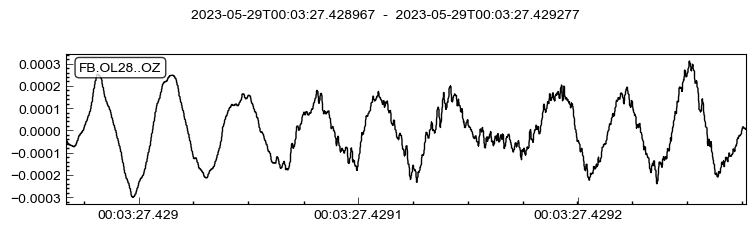

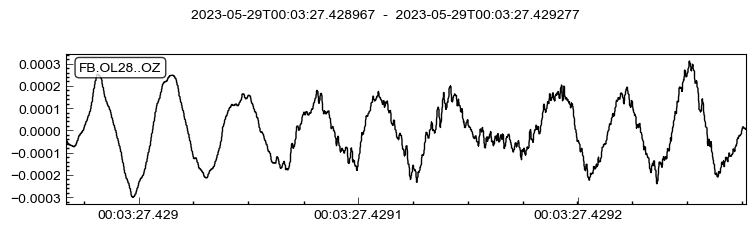

In [27]:
tr_stage2.plot()

In [28]:
# print(st_eventsta.__str__(extended=True))

In [29]:
event_case

'fb03-087__0115'

In [30]:
# plot comparison with and without instrumental response removal
event_case = "fb03-087__0029"
stnm = "OL12"
finame = os.path.join(outputdir, "{}_AEwaveform.pickle".format(event_case)) 
st_event = read(finame) # this contains observation and green's function within a thresholded distance
tr_wrem = st_event.select(station=stnm, location="stage1", channel="OZ")[0]
tr_norem = st_event.select(station=stnm, location="raw", channel="OZ")[0]

In [31]:
print(st_event.__str__(extended=True))

60 Trace(s) in Stream:
FB.OL10.stage1.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.raw.OZ      | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage3.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage2.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxx | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxy | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxz | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myy | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myz | 2023-05-29T00:01:19.31665300Z - 2023-05-29T

In [32]:
print(st_event.__str__(extended=True))

60 Trace(s) in Stream:
FB.OL10.stage1.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.raw.OZ      | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage3.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage2.OZ   | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxx | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxy | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxz | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myy | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myz | 2023-05-29T00:01:19.31665300Z - 2023-05-29T

In [51]:
# stnm_list = np.unique([tr.stats.station for tr in st_event])
# manually rearrange with distance from source
stnm_list = ["OL27", "OL11", "OL12", "OL26", "OL28", "OL10"]


In [52]:
pretrigger = tr_wrem.stats

[-0.2, 0.2]
[-0.2, 0.2]
[-0.4, 0.4]
[-0.4, 0.4]
[-0.2, 0.2]
[-0.1, 0.1]


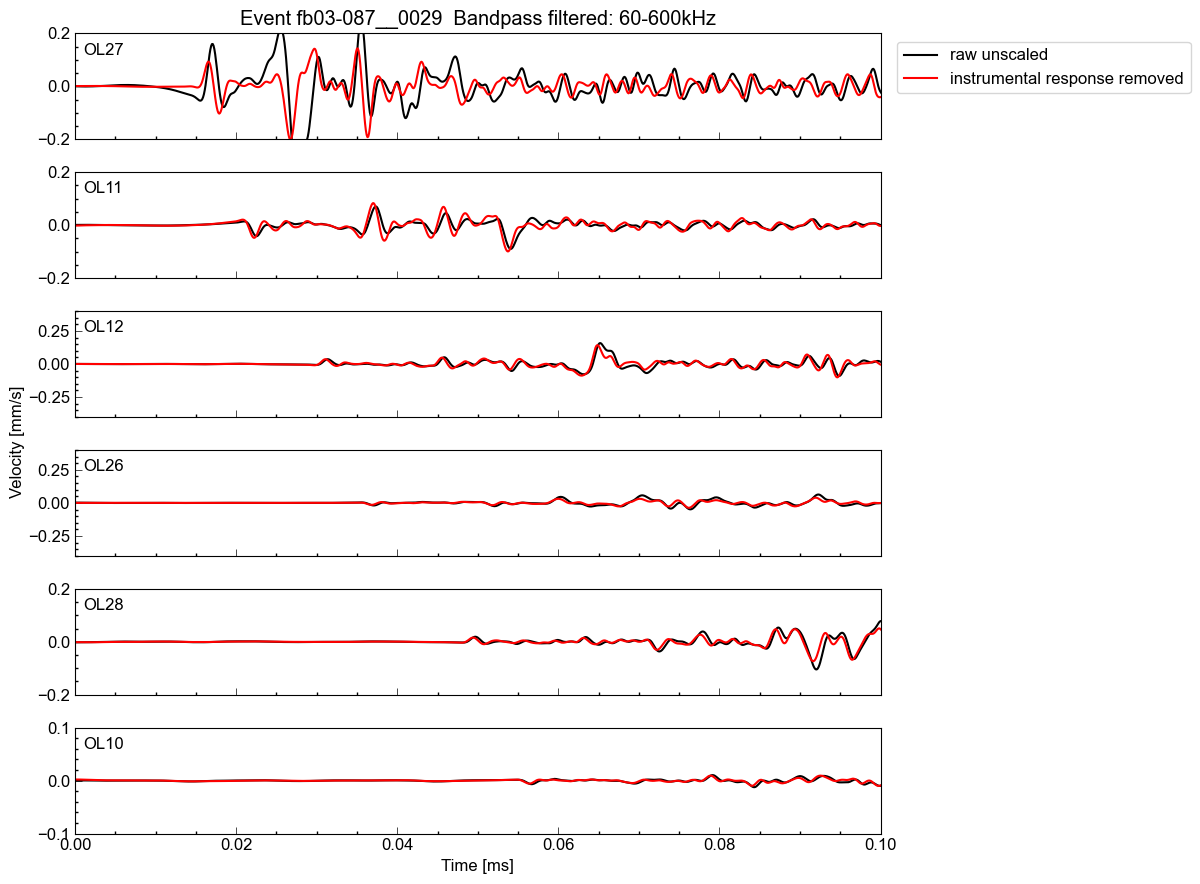

In [53]:
Nsensor = len(stnm_list)
fig, axs = plt.subplots(Nsensor, 1, figsize=(12, 9), sharex=True)

freqmin = 6e4
freqmax = 6e5
xlimit = [0, 0.1]
ylimits =[0.2, 0.2, 0.4, 0.4, 0.2, 0.1] 
scale_fac = 5000 # emperical scaling factor; which is estimated from ball drop test

for i, stnm in enumerate(stnm_list):

    tr_wrem = st_event.select(station=stnm, location="stage1", channel="OZ")[0]
    tr_norem = st_event.select(station=stnm, location="raw", channel="OZ")[0]

    # apply bandpass filter

    tr_wrem_filtered = tr_wrem.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=2, zerophase=True)
    tr_norem_filtered = tr_norem.copy().filter("bandpass", freqmin=freqmin, freqmax=freqmax, corners=2, zerophase=True)

    # 1. plot entire trace
    tvec = (tr_wrem_filtered.times())*1e3 - tr_wrem_filtered.stats.pretrigger
    axs[i].plot(tvec, tr_norem_filtered.data*1e3/scale_fac, "k-")
    axs[i].plot(tvec, tr_wrem_filtered.data*1e3, "r-")
    axs[i].set_xlim(xlimit)

    # set ylim
    fs = tr_wrem_filtered.stats.delta 
    tmax_ind = np.min(np.where(tvec>xlimit[1]))
    ylim_amp_filt = 1.2*np.maximum(np.max(np.abs(tr_norem_filtered.data[:tmax_ind]*1e3)), np.max(np.abs(tr_wrem_filtered.data[:tmax_ind]*1e3)))
#     axs[i].set_ylim([-ylim_amp_filt, ylim_amp_filt])
    axs[i].set_ylim([-ylimits[i], ylimits[i]])
    print([-ylimits[i], ylimits[i]])
    axs[i].text(0.01, 0.8, f"{stnm}", transform=axs[i].transAxes)

axs[0].set_title(r"Event {}  Bandpass filtered: {:.0f}-{:.0f}kHz".format(event_case, freqmin/1e3, freqmax/1e3))
fig.text(0.0, 0.5, 'Velocity [mm/s]', va='center', rotation='vertical')

axs[-1].set_xlabel("Time [ms]")

axs[0].legend(["raw unscaled", "instrumental response removed"], bbox_to_anchor=(1.01, 1.0), loc="upper left")

plt.tight_layout()
plt.savefig(figdir+"/comparison_response_removal_event{}.png".format(event_case), dpi=300)

        

In [54]:
tr_obs_trim.stats.starttime

2023-05-29T00:03:27.42896700Z

In [55]:
starttime_tmp

2025-12-03T11:24:52.99999000Z

In [56]:
# tr_obs.stats.tpick

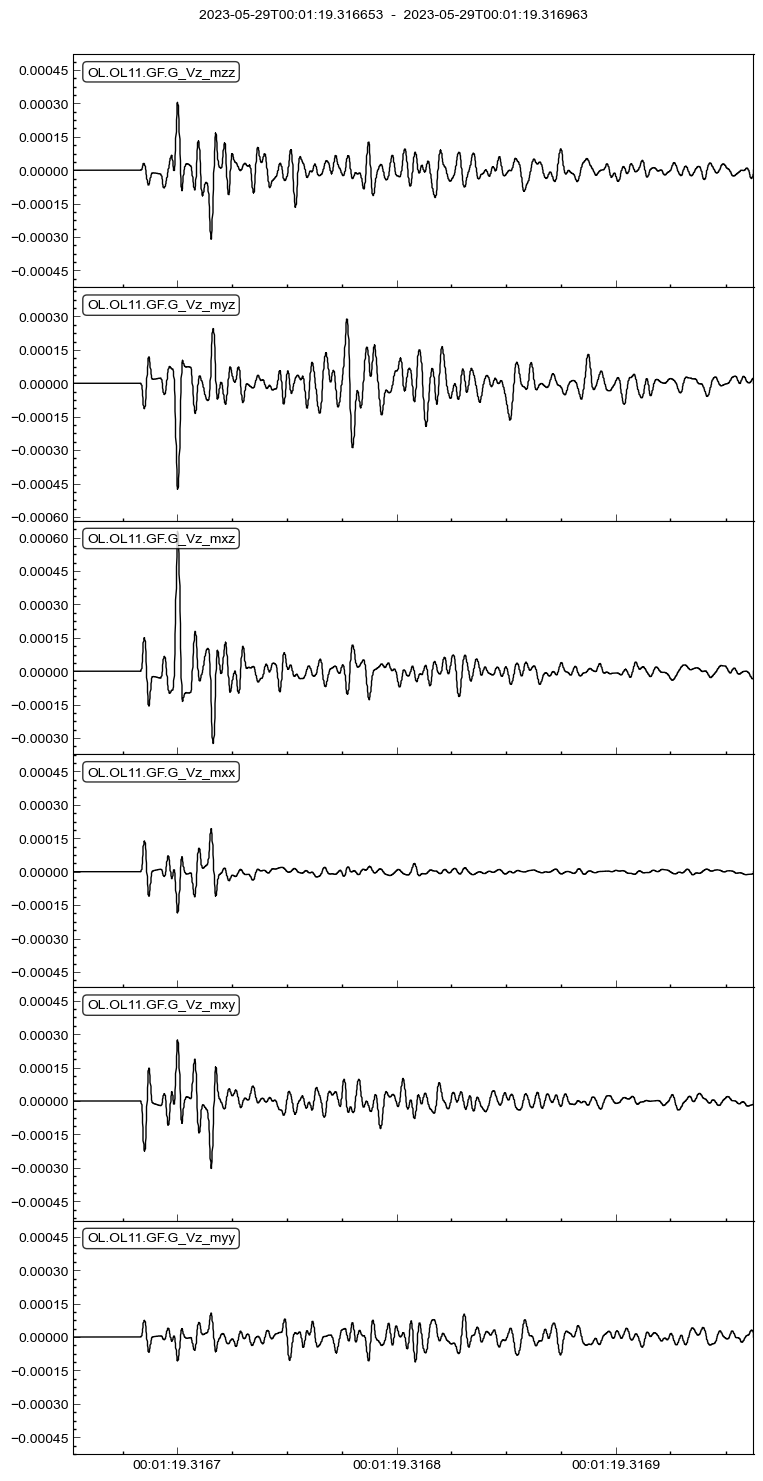

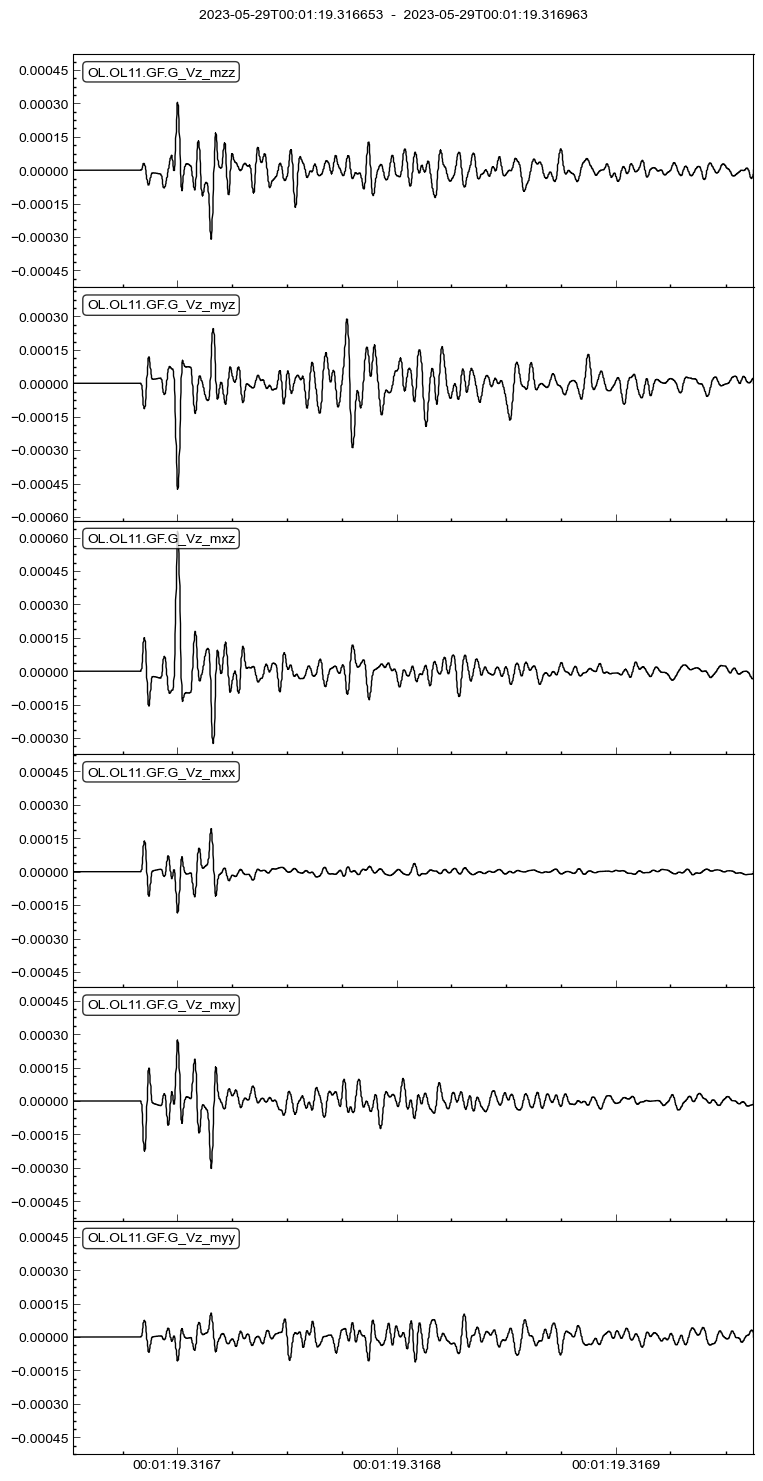

In [57]:
st_event.select(location="GF", station="OL11").plot()

In [58]:
st_event.select(station='OL27', location='stage1', channel='OZ')[0].stats

         network: FB
         station: OL27
        location: stage1
         channel: OZ
       starttime: 2023-05-29T00:01:19.31665300Z
         endtime: 2023-05-29T00:01:19.31696300Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 3101
           calib: 1.0
         _format: PICKLE
       dataindex: OL27__fb03-087__0029
            dist: 93.311641824587
            eta1: -0.044250000000000005
      origintime: 79.316753
      pretrigger: 0.01
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2023, 5, 29, 0, 1, 19, 317053)::fill_value=0.0::nearest_sample=True::pad=True::starttime=UTCDateTime(2023, 5, 29, 0, 1, 19, 316743))', "ObsPy 1.4.1: filter(options={'freq': 60000.0}::type='highpass')"]
           tpick: 0.015050264810417258
       windowlen: 0.3
             xi1: 0.04300000000000015
           zeta1: 0

In [59]:
print(st_eventsta.__str__(extended=True))

60 Trace(s) in Stream:
FB.OL10.stage1.OZ   | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
FB.OL10.raw.OZ      | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage3.OZ   | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
FB.OL10.stage2.OZ   | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxx | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxy | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_mxz | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myy | 2023-05-29T00:03:27.42896700Z - 2023-05-29T00:03:27.42927700Z | 10000000.0 Hz, 3101 samples
OL.OL10.GF.G_Vz_myz | 2023-05-29T00:03:27.42896700Z - 2023-05-29T

In [60]:
st_event[0].stats

         network: FB
         station: OL10
        location: stage1
         channel: OZ
       starttime: 2023-05-29T00:01:19.31665300Z
         endtime: 2023-05-29T00:01:19.31696300Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 3101
           calib: 1.0
         _format: PICKLE
       dataindex: OL10__fb03-087__0029
            dist: 343.8488948651717
            eta1: -0.05575
      origintime: 79.316753
      pretrigger: 0.01
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2023, 5, 29, 0, 1, 19, 317053)::fill_value=0.0::nearest_sample=True::pad=True::starttime=UTCDateTime(2023, 5, 29, 0, 1, 19, 316743))']
           tpick: 0.055459499171801895
       windowlen: 0.3
             xi1: 0.33199999999999985
           zeta1: 0

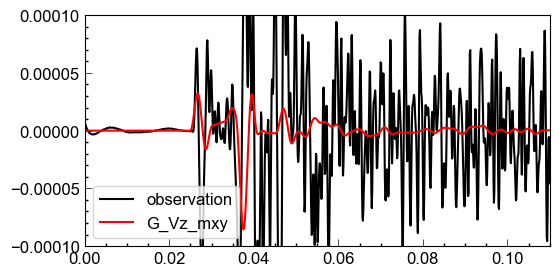

In [61]:
# check comparison
# xlimit = [0.00095, 0.00115] #[-1.5, 20.5]
ylimit = [-1e-4, 1e-4]
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
m0 = 0.1

stationid = 27
if stationid>16:
    gfsign = -1
else:
    gfsign = 1
        
tr_obs = st_event.select(station=f'OL{stationid:02d}', location='stage1')[0].filter("highpass", freq=6e4)
tr_green_xy = st_event.select(station=f'OL{stationid:02d}', location='GF', channel='G_Vz_mxy')[0]

ax.plot(tr_obs.times()*1e3, tr_obs.data, 'k-', label="observation")
ax.plot(tr_green_xy.times()*1e3, gfsign*tr_green_xy.data * m0, 'r-', label="G_Vz_mxy")

ax.axvline(tr_obs.stats.pretrigger + tr_obs.stats.tpick*1e3, lw=2, c='b')
ax.set_xlim(tr_obs.stats.pretrigger-0.01, tr_obs.stats.pretrigger+0.1)
ax.set_ylim(ylimit)
ax.legend()

In [62]:
tr_green_xy

OL.OL27.GF.G_Vz_mxy | 2023-05-29T00:01:19.31665300Z - 2023-05-29T00:01:19.31696300Z | 10000000.0 Hz, 3101 samples

In [63]:
tr_green_xy.stats

         network: OL
         station: OL27
        location: GF
         channel: G_Vz_mxy
       starttime: 2023-05-29T00:01:19.31665300Z
         endtime: 2023-05-29T00:01:19.31696300Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 3101
           calib: 1.0
         _format: PICKLE
       dataindex: OL27__fb03-087__0029
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2025, 12, 3, 11, 24, 53, 300)::fill_value=0.0::nearest_sample=True::pad=True::starttime=UTCDateTime(2025, 12, 3, 11, 24, 52, 999990))']
             sac: AttribDict({'delta': 1e-07, 'b': 0.0, 'stla': 35.7182, 'stlo': 139.7604, 'stdp': 0.0, 'evla': 35.7182, 'evlo': 139.7604, 'evdp': 0.04425, 'user0': 4.3e-05, 'user1': 0.0, 'user2': 4.425e-05, 'user3': 4.2750005e-05, 'user4': -2.500019e-07, 'user5': 4.425e-05, 'user6': 139.7604, 'user7': 35.7182, 'user8': 0.0, 'dist': 0.0, 'az': 0.0, 'baz': 0.0, 'gcarc': 0.0, 'cmpaz': 0.0, 'cmpinc': 0.0, 'nzyear': 2025, 'nzjday': 337, 'nzhour': 11, 'nzmi

In [64]:
tr_obs.stats.tpick

0.015050264810417258

In [47]:
tr_green = st_eventsta.select(station='OL12', location='GF', channel='G_Vz_mxy')[0]
tr_green.stats

         network: OL
         station: OL12
        location: GF
         channel: G_Vz_mxy
       starttime: 2023-05-29T00:03:27.42896700Z
         endtime: 2023-05-29T00:03:27.42927700Z
   sampling_rate: 10000000.0
           delta: 1e-07
            npts: 3101
           calib: 1.0
         _format: SAC
       dataindex: OL12__fb03-087__0115
      processing: ['ObsPy 1.4.1: trim(endtime=UTCDateTime(2025, 12, 3, 11, 24, 53, 300)::fill_value=0.0::nearest_sample=True::pad=True::starttime=UTCDateTime(2025, 12, 3, 11, 24, 52, 999990))']
             sac: AttribDict({'delta': 1e-07, 'b': 0.0, 'stla': 35.7182, 'stlo': 139.7604, 'stdp': 0.0, 'evla': 35.7182, 'evlo': 139.7604, 'evdp': 0.05325, 'user0': -0.000165, 'user1': 0.0, 'user2': 5.325e-05, 'user3': -0.00016524999, 'user4': -2.500019e-07, 'user5': 5.325e-05, 'user6': 139.7604, 'user7': 35.7182, 'user8': 0.0, 'dist': 0.0, 'az': 0.0, 'baz': 0.0, 'gcarc': 0.0, 'cmpaz': 0.0, 'cmpinc': 0.0, 'nzyear': 2025, 'nzjday': 337, 'nzhour': 11, 'nzmi